# Train Computer Vision Model - Rice Disease Detection di Google Colab

Notebook ini digunakan untuk training ulang model deteksi penyakit daun padi KarawangPadiGuard.

Karakteristik notebook:

1. Berjalan sepenuhnya di cell Google Colab.
2. Dataset gambar diambil dari Kaggle memakai `kagglehub`: `anshulm257/rice-disease-dataset`.
3. Model memakai transfer learning `MobileNetV3Small`.
4. Output model disimpan ke Google Drive dengan nama yang kompatibel dengan `app.py`:

```text
models/mobilenetv3_rice_disease_v1_best.keras
```

Class order dibuat konsisten dengan aplikasi:

```text
Bacterial Leaf Blight, Brown Spot, Healthy Rice Leaf, Leaf Blast, Leaf scald, Sheath Blight
```

## 1. Mount Google Drive dan Set Project Root

In [ ]:
from google.colab import drive
from pathlib import Path
import os
import shutil

drive.mount('/content/drive')

# Ubah path ini jika folder proyek kamu berbeda.
PROJECT_ROOT = Path('/content/drive/MyDrive/Datathon/KarawangPadiGuard')

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(
        f"PROJECT_ROOT tidak ditemukan: {PROJECT_ROOT}\n"
        "Ubah PROJECT_ROOT sesuai lokasi folder proyek di Google Drive."
    )

# Drive hanya dipakai untuk hasil akhir. Jangan menulis checkpoint/log training langsung ke Drive.
DRIVE_MODEL_DIR = PROJECT_ROOT / 'models'
DRIVE_REPORT_DIR = PROJECT_ROOT / 'reports'
DRIVE_LOG_DIR = PROJECT_ROOT / 'logs'

# Storage lokal Colab lebih stabil untuk checkpoint Keras dan CSVLogger.
WORK_DIR = Path('/content/karawangpadi_cv_training')
MODEL_DIR = WORK_DIR / 'models'
REPORT_DIR = WORK_DIR / 'reports'
LOG_DIR = WORK_DIR / 'logs'

for directory in [DRIVE_MODEL_DIR, DRIVE_REPORT_DIR, DRIVE_LOG_DIR, MODEL_DIR, REPORT_DIR, LOG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT    : {PROJECT_ROOT}")
print(f"LOCAL WORK_DIR  : {WORK_DIR}")
print(f"LOCAL MODEL_DIR : {MODEL_DIR}")
print(f"DRIVE MODEL_DIR : {DRIVE_MODEL_DIR}")
print("\nCatatan: training menulis ke /content dulu, lalu artifact final disalin ke Google Drive di cell akhir.")

Mounted at /content/drive
PROJECT_ROOT    : /content/drive/MyDrive/Datathon/KarawangPadiGuard
LOCAL WORK_DIR  : /content/karawangpadi_cv_training
LOCAL MODEL_DIR : /content/karawangpadi_cv_training/models
DRIVE MODEL_DIR : /content/drive/MyDrive/Datathon/KarawangPadiGuard/models

Catatan: training menulis ke /content dulu, lalu artifact final disalin ke Google Drive di cell akhir.


## 2. Install dan Import Dependencies

In [ ]:
import sys
import subprocess

packages = [
    'kagglehub',
    'tensorflow',
    'numpy',
    'pandas',
    'scikit-learn',
    'matplotlib',
    'seaborn',
    'Pillow',
]

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *packages])

import json
import random
import shutil
import warnings
from datetime import datetime
from pathlib import Path

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, applications, mixed_precision
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid', palette='Set2')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU devices: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Runtime Config

Default dibuat praktis untuk Colab T4. Jika ingin hasil lebih kuat, naikkan `EPOCHS` dan `FINE_TUNE_EPOCHS`.

In [ ]:
CONFIG = {
    'model_name': 'mobilenetv3_rice_disease_v1',
    'dataset_slug': 'anshulm257/rice-disease-dataset',
    'img_size': (224, 224),
    'batch_size': 32,
    'epochs': 20,
    'fine_tune_epochs': 10,
    'learning_rate': 1e-3,
    'fine_tune_learning_rate': 1e-4,
    'fine_tune_trainable_layers': 30,
    'validation_split': 0.2,
    'test_split': 0.1,
    'use_mixed_precision': True,
    'cache_dataset': False,
    'shuffle_buffer_size': 2048,
}

CLASS_NAMES = [
    'Bacterial Leaf Blight',
    'Brown Spot',
    'Healthy Rice Leaf',
    'Leaf Blast',
    'Leaf scald',
    'Sheath Blight',
]

CLASS_NAMES_ID = [
    'Hawar Daun Bakteri',
    'Bercak Coklat',
    'Daun Sehat',
    'Blas Daun',
    'Hawar Seludang',
    'Blas Seludang',
]

IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

# Mixed precision hanya diaktifkan kalau GPU tersedia.
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as err:
            print(f"Could not set memory growth: {err}")

    if CONFIG['use_mixed_precision']:
        mixed_precision.set_global_policy('mixed_float16')
        print(f"Mixed precision policy: {mixed_precision.global_policy()}")
else:
    print('GPU tidak terdeteksi. Training tetap bisa berjalan, tetapi akan lebih lambat.')

print(CONFIG)

Mixed precision policy: <DTypePolicy "mixed_float16">
{'model_name': 'mobilenetv3_rice_disease_v1', 'dataset_slug': 'anshulm257/rice-disease-dataset', 'img_size': (224, 224), 'batch_size': 32, 'epochs': 20, 'fine_tune_epochs': 10, 'learning_rate': 0.001, 'fine_tune_learning_rate': 0.0001, 'fine_tune_trainable_layers': 30, 'validation_split': 0.2, 'test_split': 0.1, 'use_mixed_precision': True, 'cache_dataset': False, 'shuffle_buffer_size': 2048}


## 4. Download Dataset Gambar dari Kaggle

In [ ]:
dataset_download_path = Path(kagglehub.dataset_download(CONFIG['dataset_slug']))
print(f"Downloaded dataset path: {dataset_download_path}")


def count_images_in_class_dirs(candidate):
    candidate = Path(candidate)
    if not candidate.exists() or not candidate.is_dir():
        return 0, []

    class_dirs = [child for child in candidate.iterdir() if child.is_dir()]
    valid_class_dirs = []
    total_images = 0

    for class_dir in class_dirs:
        image_count = sum(
            1 for path in class_dir.rglob('*')
            if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
        )
        if image_count > 0:
            valid_class_dirs.append((class_dir, image_count))
            total_images += image_count

    return total_images, valid_class_dirs


def find_dataset_root(download_path):
    candidates = [
        download_path / 'Rice_Leaf_AUG',
        download_path,
    ]

    # Cek sampai dua level, cukup untuk struktur Kaggle dataset ini tanpa deep scan mahal.
    for level_1 in [p for p in download_path.iterdir() if p.is_dir()]:
        candidates.append(level_1)
        for level_2 in [p for p in level_1.iterdir() if p.is_dir()]:
            candidates.append(level_2)

    scored = []
    for candidate in candidates:
        total_images, class_dirs = count_images_in_class_dirs(candidate)
        if len(class_dirs) >= 2:
            scored.append((total_images, candidate, class_dirs))

    if not scored:
        raise FileNotFoundError(f"Tidak menemukan folder class berisi gambar di {download_path}")

    scored.sort(key=lambda item: item[0], reverse=True)
    return scored[0][1], scored[0][2]

DATASET_ROOT, detected_class_dirs = find_dataset_root(dataset_download_path)
print(f"DATASET_ROOT: {DATASET_ROOT}")
print('Detected class folders:')
for class_dir, count in detected_class_dirs:
    print(f"- {class_dir.name}: {count} images")

100%|██████████| 0.99G/0.99G [00:57<00:00, 18.6MB/s]

Extracting files...


Downloaded dataset path: /root/.cache/kagglehub/datasets/anshulm257/rice-disease-dataset/versions/1
DATASET_ROOT: /root/.cache/kagglehub/datasets/anshulm257/rice-disease-dataset/versions/1/Rice_Leaf_AUG
Detected class folders:
- Leaf Blast: 634 images
- Healthy Rice Leaf: 653 images
- Bacterial Leaf Blight: 636 images
- Sheath Blight: 632 images
- Leaf scald: 628 images
- Brown Spot: 646 images


## 5. Scan Dataset dan Validasi Class Order

Total images: 3,829
class_name
Bacterial Leaf Blight    636
Brown Spot               646
Healthy Rice Leaf        653
Leaf Blast               634
Leaf scald               628
Sheath Blight            632
Name: count, dtype: int64


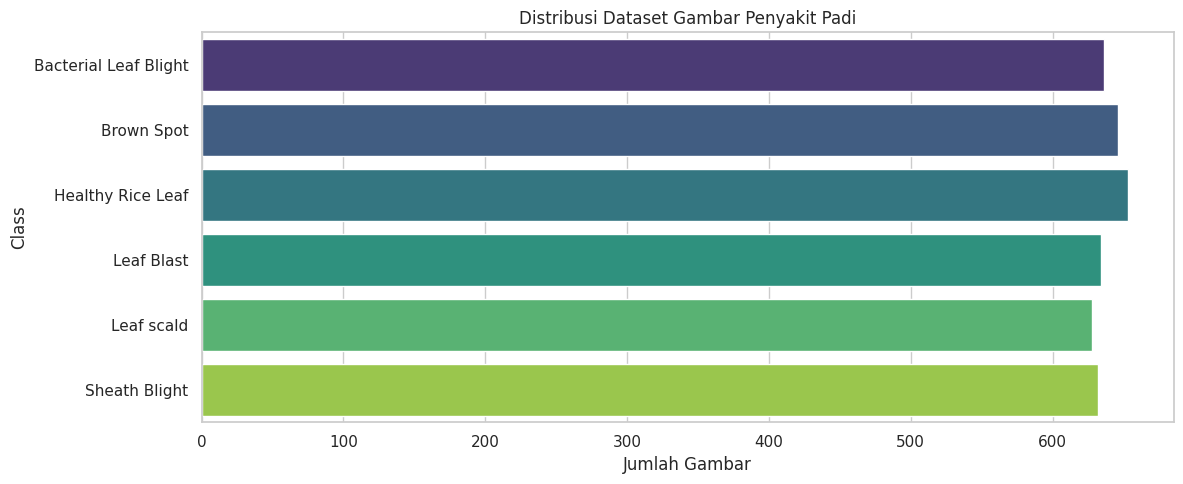

In [ ]:
def list_images_with_labels(dataset_root, class_names):
    rows = []
    missing_classes = []

    for label_idx, class_name in enumerate(class_names):
        class_dir = Path(dataset_root) / class_name
        if not class_dir.exists():
            missing_classes.append(class_name)
            continue

        image_paths = sorted([
            path for path in class_dir.rglob('*')
            if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
        ])

        for image_path in image_paths:
            rows.append({
                'filepath': str(image_path),
                'class_name': class_name,
                'label': label_idx,
            })

    if missing_classes:
        raise FileNotFoundError(
            f"Class folder berikut tidak ditemukan di DATASET_ROOT: {missing_classes}\n"
            f"Folder tersedia: {[p.name for p in Path(dataset_root).iterdir() if p.is_dir()]}"
        )

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError('Tidak ada gambar yang ditemukan.')

    return df

image_df = list_images_with_labels(DATASET_ROOT, CLASS_NAMES)
print(f"Total images: {len(image_df):,}")
print(image_df['class_name'].value_counts().reindex(CLASS_NAMES))

plt.figure(figsize=(12, 5))
sns.countplot(data=image_df, y='class_name', order=CLASS_NAMES, palette='viridis')
plt.title('Distribusi Dataset Gambar Penyakit Padi')
plt.xlabel('Jumlah Gambar')
plt.ylabel('Class')
plt.tight_layout()
plt.show()

## 6. Split Train/Validation/Test

In [ ]:
train_df, holdout_df = train_test_split(
    image_df,
    test_size=CONFIG['validation_split'] + CONFIG['test_split'],
    random_state=SEED,
    stratify=image_df['label'],
)

relative_test_size = CONFIG['test_split'] / (CONFIG['validation_split'] + CONFIG['test_split'])
val_df, test_df = train_test_split(
    holdout_df,
    test_size=relative_test_size,
    random_state=SEED,
    stratify=holdout_df['label'],
)

print(f"Train: {len(train_df):,}")
print(f"Val  : {len(val_df):,}")
print(f"Test : {len(test_df):,}")

split_summary = pd.DataFrame({
    'train': train_df['class_name'].value_counts().reindex(CLASS_NAMES),
    'val': val_df['class_name'].value_counts().reindex(CLASS_NAMES),
    'test': test_df['class_name'].value_counts().reindex(CLASS_NAMES),
}).fillna(0).astype(int)

split_summary

Train: 2,680
Val  : 766
Test : 383


,train,val,test
class_name,,,
Bacterial Leaf Blight,445,127,64
Brown Spot,452,129,65
Healthy Rice Leaf,457,131,65
Leaf Blast,444,127,63
Leaf scald,440,125,63
Sheath Blight,442,127,63


## 7. Build `tf.data` Pipeline

In [ ]:
def decode_and_resize_image(file_path, label):
    image = tf.io.read_file(file_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, CONFIG['img_size'])
    image = tf.cast(image, tf.float32)
    label = tf.one_hot(label, depth=len(CLASS_NAMES))
    return image, label


def build_dataset(df, training=False):
    file_paths = df['filepath'].values
    labels = df['label'].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    if training:
        ds = ds.shuffle(
            buffer_size=min(len(df), CONFIG['shuffle_buffer_size']),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    ds = ds.map(decode_and_resize_image, num_parallel_calls=tf.data.AUTOTUNE)

    if CONFIG['cache_dataset']:
        ds = ds.cache()

    ds = ds.batch(CONFIG['batch_size']).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = build_dataset(train_df, training=True)
val_ds = build_dataset(val_df, training=False)
test_ds = build_dataset(test_df, training=False)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(CLASS_NAMES)),
    y=train_df['label'].values,
)
CLASS_WEIGHTS = {idx: float(weight) for idx, weight in enumerate(class_weights_array)}
print('Class weights:')
print(CLASS_WEIGHTS)

batch_images, batch_labels = next(iter(train_ds))
print(f"Batch images shape: {batch_images.shape}")
print(f"Batch labels shape : {batch_labels.shape}")

Class weights:
{0: 1.00374531835206, 1: 0.9882005899705014, 2: 0.9773887673231219, 3: 1.006006006006006, 4: 1.0151515151515151, 5: 1.0105580693815988}
Batch images shape: (32, 224, 224, 3)
Batch labels shape : (32, 6)


## 8. Preview Sample Gambar

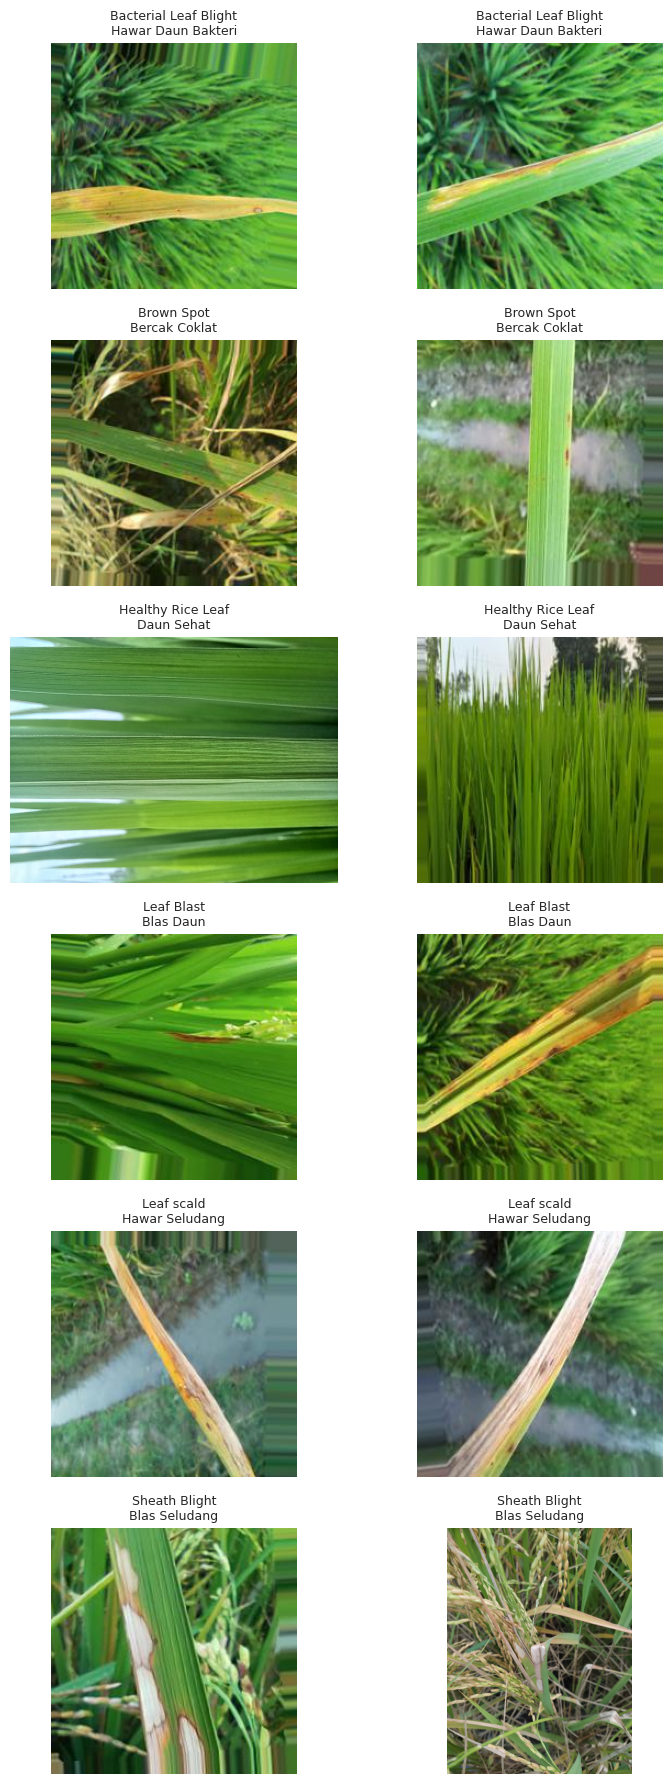

In [ ]:
sample_df = image_df.groupby('class_name', group_keys=False).apply(lambda x: x.sample(2, random_state=SEED))

fig, axes = plt.subplots(len(CLASS_NAMES), 2, figsize=(8, 18))
for row_idx, class_name in enumerate(CLASS_NAMES):
    class_samples = sample_df[sample_df['class_name'] == class_name].head(2)
    for col_idx, (_, sample) in enumerate(class_samples.iterrows()):
        img = Image.open(sample['filepath']).convert('RGB')
        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].axis('off')
        axes[row_idx, col_idx].set_title(f"{class_name}\n{CLASS_NAMES_ID[CLASS_NAMES.index(class_name)]}", fontsize=9)

plt.tight_layout()
plt.show()

## 9. Build MobileNetV3Small Model

In [ ]:
def build_model(num_classes):
    data_augmentation = models.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.10),
    ], name='data_augmentation')

    base_model = applications.MobileNetV3Small(
        input_shape=(*CONFIG['img_size'], 3),
        include_top=False,
        weights='imagenet',
        include_preprocessing=True,
    )
    base_model.trainable = False

    inputs = layers.Input(shape=(*CONFIG['img_size'], 3))
    x = data_augmentation(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.20)(x)
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = models.Model(inputs, outputs, name=CONFIG['model_name'])
    return model, base_model


def compile_model(model, learning_rate):
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
            keras.metrics.AUC(name='auc'),
        ],
    )
    return model

model, base_model = build_model(num_classes=len(CLASS_NAMES))
model = compile_model(model, CONFIG['learning_rate'])
model.summary()

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "mobilenetv3_rice_disease_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,088,374 (4.15 MB)

 Trainable params: 149,254 (583.02 KB)

 Non-trainable params: 939,120 (3.58 MB)

## 10. Training Transfer Learning

Checkpoint dan training log disimpan dulu ke `/content/karawangpadi_cv_training`, bukan langsung ke Google Drive. Ini mencegah error `Transport endpoint is not connected` saat Drive mount terputus ketika training berjalan.

In [ ]:
best_model_path = MODEL_DIR / f"{CONFIG['model_name']}_best.keras"
training_log_path = LOG_DIR / f"{CONFIG['model_name']}_training_log.csv"

callbacks = [
    ModelCheckpoint(
        filepath=str(best_model_path),
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1,
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=6,
        mode='max',
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
    CSVLogger(str(training_log_path)),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CONFIG['epochs'],
    callbacks=callbacks,
    class_weight=CLASS_WEIGHTS,
    verbose=1,
)

print(f"Best model checkpoint: {best_model_path}")

Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.3922 - auc: 0.7427 - loss: 1.5228 - precision: 0.5417 - recall: 0.2032
Epoch 1: val_accuracy improved from None to 0.68016, saving model to /content/karawangpadi_cv_training/models/mobilenetv3_rice_disease_v1_best.keras

Epoch 1: finished saving model to /content/karawangpadi_cv_training/models/mobilenetv3_rice_disease_v1_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 82s 593ms/step - accuracy: 0.4978 - auc: 0.8289 - loss: 1.2817 - precision: 0.6546 - recall: 0.3168 - val_accuracy: 0.6802 - val_auc: 0.9246 - val_loss: 0.8801 - val_precision: 0.8000 - val_recall: 0.5326 - learning_rate: 0.0010
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.6255 - auc: 0.9021 - loss: 0.9860 - precision: 0.7233 - recall: 0.4995
Epoch 2: val_accuracy improved from 0.68016 to 0.73629, saving model to /content/karawangpadi_cv_training/models/mobilenetv3_rice_disease_v1_best.keras

Epoch 2: finished saving model to /content/karawangpa

## 11. Fine-Tuning

In [ ]:
RUN_FINE_TUNING = True
history_fine = None

if RUN_FINE_TUNING and CONFIG['fine_tune_epochs'] > 0:
    base_model.trainable = True

    for layer in base_model.layers[:-CONFIG['fine_tune_trainable_layers']]:
        layer.trainable = False

    model = compile_model(model, CONFIG['fine_tune_learning_rate'])

    fine_tune_callbacks = [
        ModelCheckpoint(
            filepath=str(best_model_path),
            monitor='val_accuracy',
            mode='max',
            save_best_only=True,
            verbose=1,
        ),
        EarlyStopping(
            monitor='val_accuracy',
            patience=4,
            mode='max',
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            min_lr=1e-7,
            verbose=1,
        ),
    ]

    history_fine = model.fit(
        train_ds,
        validation_data=val_ds,
        initial_epoch=len(history.history['loss']),
        epochs=len(history.history['loss']) + CONFIG['fine_tune_epochs'],
        callbacks=fine_tune_callbacks,
        class_weight=CLASS_WEIGHTS,
        verbose=1,
    )
else:
    print('Fine-tuning dilewati.')

Epoch 21/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.6179 - auc: 0.8718 - loss: 1.5606 - precision: 0.6494 - recall: 0.5900
Epoch 21: val_accuracy improved from None to 0.73238, saving model to /content/karawangpadi_cv_training/models/mobilenetv3_rice_disease_v1_best.keras

Epoch 21: finished saving model to /content/karawangpadi_cv_training/models/mobilenetv3_rice_disease_v1_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 45s 310ms/step - accuracy: 0.6784 - auc: 0.9111 - loss: 1.0832 - precision: 0.7208 - recall: 0.6425 - val_accuracy: 0.7324 - val_auc: 0.9499 - val_loss: 0.7140 - val_precision: 0.7625 - val_recall: 0.6958 - learning_rate: 1.0000e-04
Epoch 22/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.7399 - auc: 0.9562 - loss: 0.6595 - precision: 0.7901 - recall: 0.6983
Epoch 22: val_accuracy improved from 0.73238 to 0.75849, saving model to /content/karawangpadi_cv_training/models/mobilenetv3_rice_disease_v1_best.keras

Epoch 22: finished saving model to /content/

## 12. Visualisasi Training History

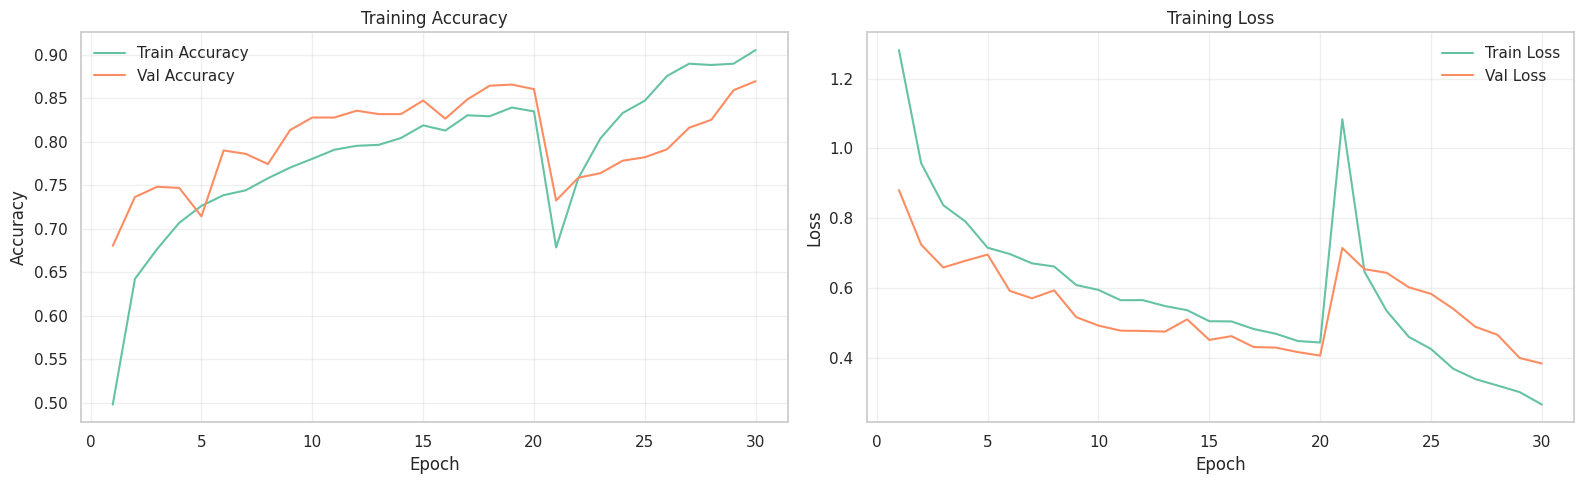

Saved: /content/karawangpadi_cv_training/reports/mobilenetv3_rice_disease_v1_training_history.csv
Saved: /content/karawangpadi_cv_training/reports/mobilenetv3_rice_disease_v1_training_history.png


In [ ]:
def combine_history(history, history_fine=None):
    rows = []
    for epoch_idx in range(len(history.history['loss'])):
        row = {'epoch': epoch_idx + 1, 'phase': 'transfer'}
        for key, values in history.history.items():
            row[key] = values[epoch_idx]
        rows.append(row)

    if history_fine is not None:
        offset = len(rows)
        for idx in range(len(history_fine.history['loss'])):
            row = {'epoch': offset + idx + 1, 'phase': 'fine_tune'}
            for key, values in history_fine.history.items():
                row[key] = values[idx]
            rows.append(row)

    return pd.DataFrame(rows)

history_df = combine_history(history, history_fine)
history_csv_path = REPORT_DIR / f"{CONFIG['model_name']}_training_history.csv"
history_df.to_csv(history_csv_path, index=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(history_df['epoch'], history_df['accuracy'], label='Train Accuracy')
axes[0].plot(history_df['epoch'], history_df['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Training Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_df['epoch'], history_df['loss'], label='Train Loss')
axes[1].plot(history_df['epoch'], history_df['val_loss'], label='Val Loss')
axes[1].set_title('Training Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
history_plot_path = REPORT_DIR / f"{CONFIG['model_name']}_training_history.png"
plt.savefig(history_plot_path, dpi=150)
plt.show()

print(f"Saved: {history_csv_path}")
print(f"Saved: {history_plot_path}")

## 13. Evaluasi Model di Test Set

In [ ]:
# Load checkpoint terbaik untuk evaluasi akhir.
best_model = keras.models.load_model(best_model_path)

test_loss, test_acc, test_precision, test_recall, test_auc = best_model.evaluate(test_ds, verbose=0)
y_pred_probs = best_model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true_onehot = np.concatenate([labels.numpy() for _, labels in test_ds], axis=0)
y_true = np.argmax(y_true_onehot, axis=1)

weighted_precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
weighted_recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

metrics = {
    'loss': float(test_loss),
    'accuracy': float(test_acc),
    'keras_precision': float(test_precision),
    'keras_recall': float(test_recall),
    'auc': float(test_auc),
    'precision_weighted': float(weighted_precision),
    'recall_weighted': float(weighted_recall),
    'f1_weighted': float(weighted_f1),
}

print('Test Metrics:')
for key, value in metrics.items():
    print(f"- {key}: {value:.4f}")

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).T
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CLASS_NAMES))))

report_df

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 247ms/step
Test Metrics:
- loss: 0.3602
- accuracy: 0.8851
- keras_precision: 0.9126
- keras_recall: 0.8721
- auc: 0.9861
- precision_weighted: 0.8902
- recall_weighted: 0.8851
- f1_weighted: 0.8855


,precision,recall,f1-score,support
Bacterial Leaf Blight,0.788732,0.875000,0.829630,64.000000
Brown Spot,0.890625,0.876923,0.883721,65.000000
Healthy Rice Leaf,0.970149,1.000000,0.984848,65.000000
Leaf Blast,0.850000,0.809524,0.829268,63.000000
Leaf scald,0.840580,0.920635,0.878788,63.000000
Sheath Blight,1.000000,0.825397,0.904348,63.000000
accuracy,0.885117,0.885117,0.885117,0.885117
macro avg,0.890014,0.884580,0.885101,383.000000
weighted avg,0.890172,0.885117,0.885469,383.000000


## 14. Visualisasi Evaluasi

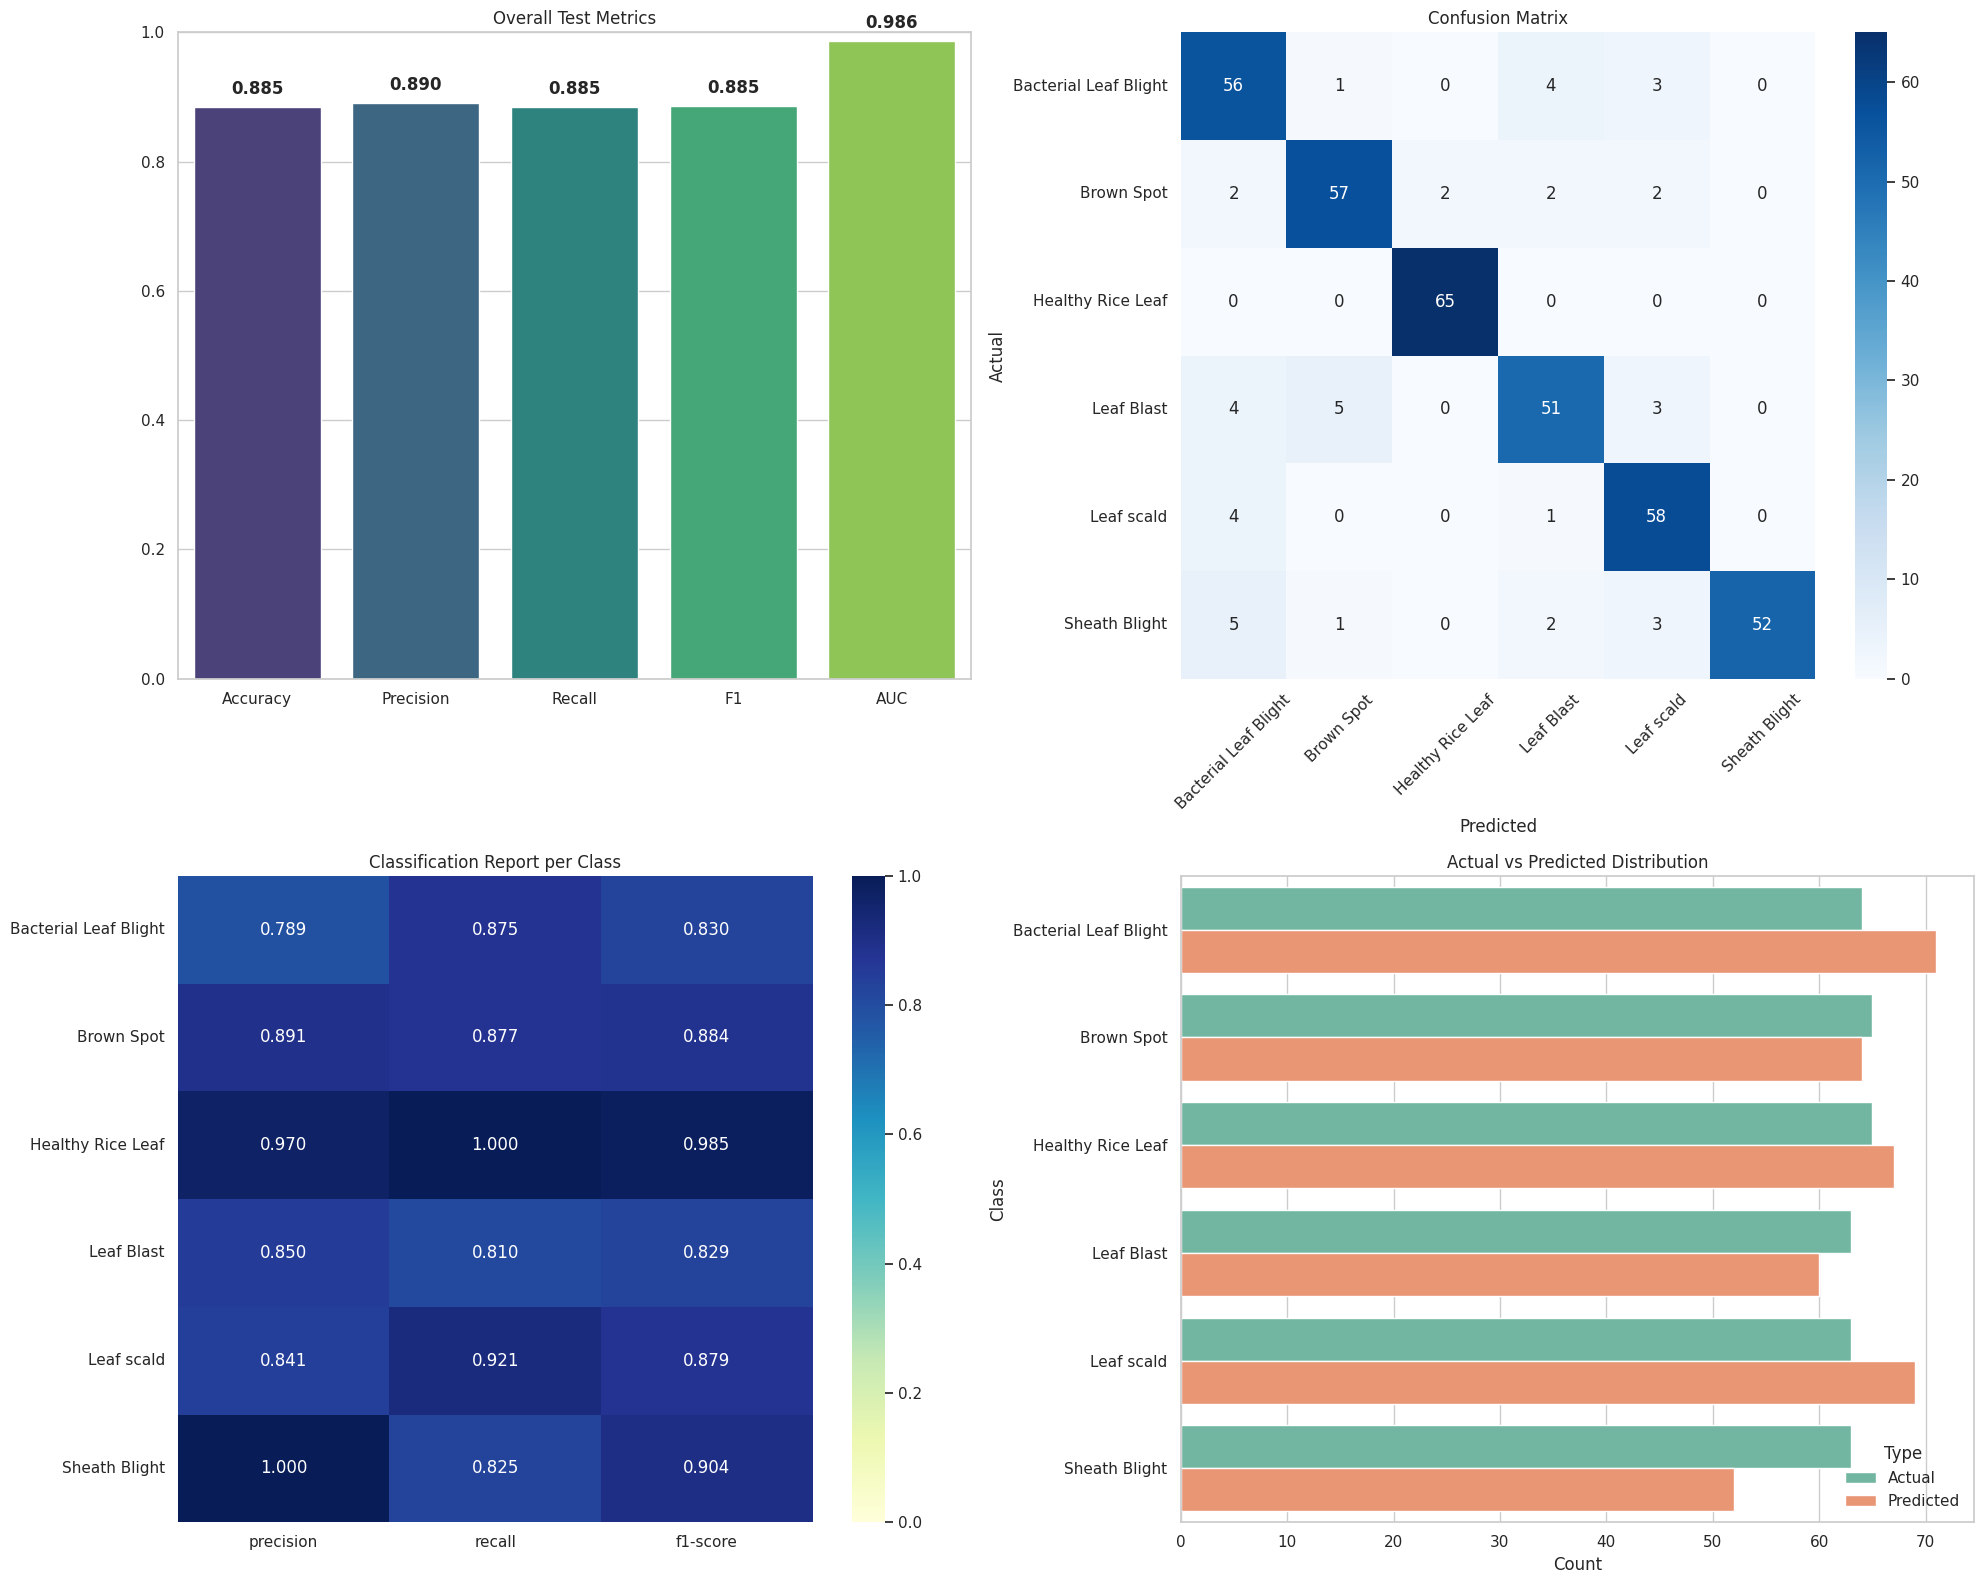

Saved: /content/karawangpadi_cv_training/reports/mobilenetv3_rice_disease_v1_evaluation.png
Saved: /content/karawangpadi_cv_training/reports/mobilenetv3_rice_disease_v1_confusion_matrix.csv
Saved: /content/karawangpadi_cv_training/reports/mobilenetv3_rice_disease_v1_classification_report.csv


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
metric_values = [
    metrics['accuracy'],
    metrics['precision_weighted'],
    metrics['recall_weighted'],
    metrics['f1_weighted'],
    metrics['auc'],
]
sns.barplot(x=metric_names, y=metric_values, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_title('Overall Test Metrics')
for idx, value in enumerate(metric_values):
    axes[0, 0].text(idx, min(value + 0.02, 1.02), f'{value:.3f}', ha='center', fontweight='bold')

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[0, 1],
)
axes[0, 1].set_title('Confusion Matrix')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].tick_params(axis='y', rotation=0)

class_report_plot = report_df.loc[CLASS_NAMES, ['precision', 'recall', 'f1-score']]
sns.heatmap(class_report_plot, annot=True, cmap='YlGnBu', vmin=0, vmax=1, fmt='.3f', ax=axes[1, 0])
axes[1, 0].set_title('Classification Report per Class')

pred_compare = pd.DataFrame({
    'Actual': pd.Categorical.from_codes(y_true, CLASS_NAMES),
    'Predicted': pd.Categorical.from_codes(y_pred, CLASS_NAMES),
})
pred_counts = pred_compare.melt(var_name='Type', value_name='Class')
sns.countplot(data=pred_counts, y='Class', hue='Type', order=CLASS_NAMES, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Actual vs Predicted Distribution')
axes[1, 1].set_xlabel('Count')
axes[1, 1].set_ylabel('Class')

plt.tight_layout()
eval_plot_path = REPORT_DIR / f"{CONFIG['model_name']}_evaluation.png"
plt.savefig(eval_plot_path, dpi=150)
plt.show()

cm_path = REPORT_DIR / f"{CONFIG['model_name']}_confusion_matrix.csv"
report_path = REPORT_DIR / f"{CONFIG['model_name']}_classification_report.csv"
pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(cm_path)
report_df.to_csv(report_path)

print(f"Saved: {eval_plot_path}")
print(f"Saved: {cm_path}")
print(f"Saved: {report_path}")

## 15. Visualisasi Sample Prediksi

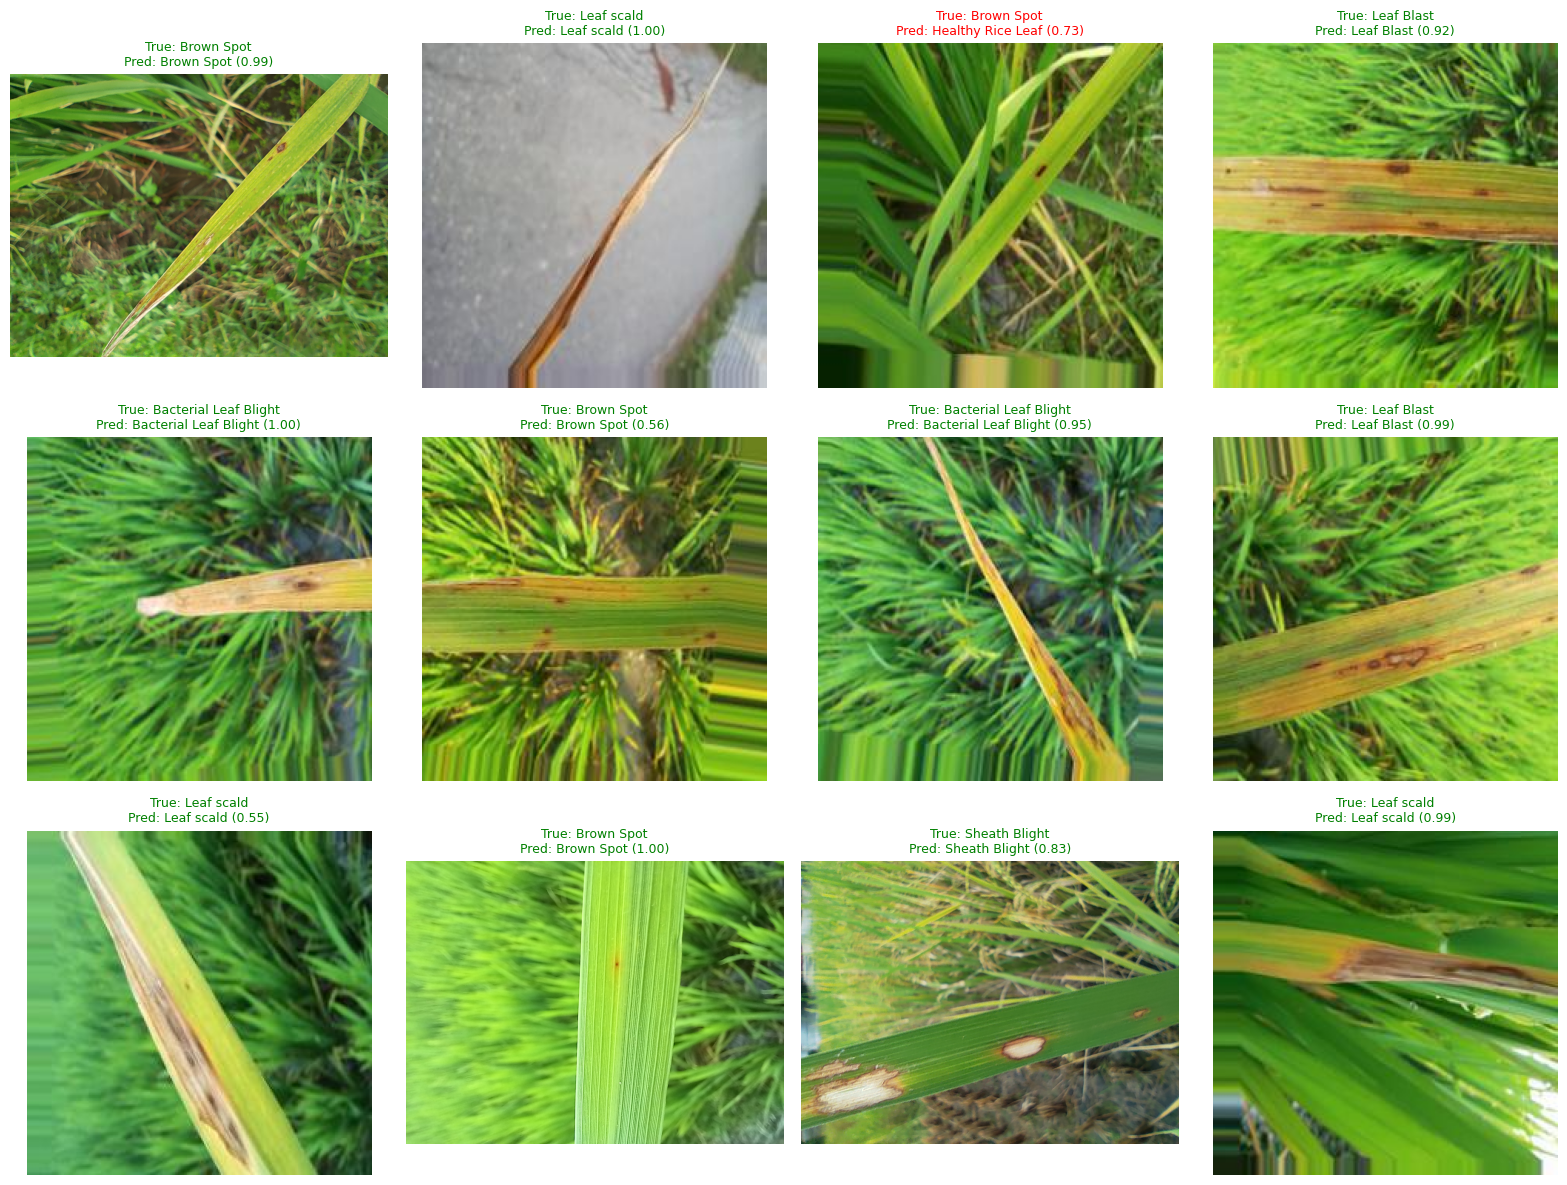

Saved: /content/karawangpadi_cv_training/reports/mobilenetv3_rice_disease_v1_sample_predictions.png


In [ ]:
sample_test_df = test_df.sample(min(12, len(test_df)), random_state=SEED).reset_index(drop=True)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, row in sample_test_df.iterrows():
    img = Image.open(row['filepath']).convert('RGB')
    img_resized = img.resize(CONFIG['img_size'])
    arr = np.array(img_resized, dtype=np.float32)[None, ...]
    pred_prob = best_model.predict(arr, verbose=0)[0]
    pred_idx = int(np.argmax(pred_prob))
    true_idx = int(row['label'])
    color = 'green' if pred_idx == true_idx else 'red'

    axes[idx].imshow(img)
    axes[idx].axis('off')
    axes[idx].set_title(
        f"True: {CLASS_NAMES[true_idx]}\nPred: {CLASS_NAMES[pred_idx]} ({pred_prob[pred_idx]:.2f})",
        color=color,
        fontsize=9,
    )

for idx in range(len(sample_test_df), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
sample_pred_path = REPORT_DIR / f"{CONFIG['model_name']}_sample_predictions.png"
plt.savefig(sample_pred_path, dpi=150)
plt.show()
print(f"Saved: {sample_pred_path}")

## 16. Simpan Model dan Artefak

In [ ]:
# Simpan final model di storage lokal Colab terlebih dahulu.
final_model_path = MODEL_DIR / f"{CONFIG['model_name']}_final.keras"
best_model.save(final_model_path)

class_mapping = {
    'class_names': CLASS_NAMES,
    'class_names_id': CLASS_NAMES_ID,
    'class_to_index': {class_name: idx for idx, class_name in enumerate(CLASS_NAMES)},
    'index_to_class': {idx: class_name for idx, class_name in enumerate(CLASS_NAMES)},
}

config_to_save = dict(CONFIG)
config_to_save['class_names'] = CLASS_NAMES
config_to_save['class_names_id'] = CLASS_NAMES_ID
config_to_save['dataset_root'] = str(DATASET_ROOT)
config_to_save['train_samples'] = int(len(train_df))
config_to_save['val_samples'] = int(len(val_df))
config_to_save['test_samples'] = int(len(test_df))
config_to_save['local_work_dir'] = str(WORK_DIR)
config_to_save['drive_project_root'] = str(PROJECT_ROOT)

metrics_to_save = {
    'timestamp': datetime.now().isoformat(),
    'model_name': CONFIG['model_name'],
    'metrics': metrics,
    'classification_report': report_dict,
    'config': config_to_save,
}

config_path = MODEL_DIR / f"{CONFIG['model_name']}_config.json"
metrics_path = MODEL_DIR / f"{CONFIG['model_name']}_metrics.json"
class_mapping_path = MODEL_DIR / f"{CONFIG['model_name']}_class_mapping.json"

with open(config_path, 'w') as f:
    json.dump(config_to_save, f, indent=2, default=str)

with open(metrics_path, 'w') as f:
    json.dump(metrics_to_save, f, indent=2, default=str)

with open(class_mapping_path, 'w') as f:
    json.dump(class_mapping, f, indent=2, default=str)

# Pastikan best model lokal berada di nama yang dibaca app.py.
local_app_model_path = MODEL_DIR / 'mobilenetv3_rice_disease_v1_best.keras'
if best_model_path != local_app_model_path:
    shutil.copy2(best_model_path, local_app_model_path)

# Copy artifact final ke Google Drive setelah training selesai.
def copy_to_drive(src_path, dst_dir):
    src_path = Path(src_path)
    dst_dir = Path(dst_dir)
    dst_dir.mkdir(parents=True, exist_ok=True)
    dst_path = dst_dir / src_path.name
    shutil.copy2(src_path, dst_path)
    return dst_path

local_model_artifacts = [
    local_app_model_path,
    final_model_path,
    config_path,
    metrics_path,
    class_mapping_path,
]
local_report_artifacts = [
    history_csv_path,
    history_plot_path,
    eval_plot_path,
    cm_path,
    report_path,
    sample_pred_path,
]
local_log_artifacts = [
    training_log_path,
]

drive_artifacts = []
for artifact_path in local_model_artifacts:
    drive_artifacts.append(copy_to_drive(artifact_path, DRIVE_MODEL_DIR))
for artifact_path in local_report_artifacts:
    drive_artifacts.append(copy_to_drive(artifact_path, DRIVE_REPORT_DIR))
for artifact_path in local_log_artifacts:
    if Path(artifact_path).exists():
        drive_artifacts.append(copy_to_drive(artifact_path, DRIVE_LOG_DIR))

print('Local artifacts:')
for artifact_path in local_model_artifacts + local_report_artifacts + local_log_artifacts:
    artifact_path = Path(artifact_path)
    if artifact_path.exists():
        print(f"- {artifact_path} ({artifact_path.stat().st_size / 1024:.1f} KB)")

print('\nCopied to Google Drive:')
for artifact_path in drive_artifacts:
    print(f"- {artifact_path} ({artifact_path.stat().st_size / 1024:.1f} KB)")

print(f"\nApp-compatible model path: {DRIVE_MODEL_DIR / 'mobilenetv3_rice_disease_v1_best.keras'}")

Local artifacts:
- /content/karawangpadi_cv_training/models/mobilenetv3_rice_disease_v1_best.keras (16395.8 KB)
- /content/karawangpadi_cv_training/models/mobilenetv3_rice_disease_v1_final.keras (16389.9 KB)
- /content/karawangpadi_cv_training/models/mobilenetv3_rice_disease_v1_config.json (1.0 KB)
- /content/karawangpadi_cv_training/models/mobilenetv3_rice_disease_v1_metrics.json (2.8 KB)
- /content/karawangpadi_cv_training/models/mobilenetv3_rice_disease_v1_class_mapping.json (0.6 KB)
- /content/karawangpadi_cv_training/reports/mobilenetv3_rice_disease_v1_training_history.csv (6.7 KB)
- /content/karawangpadi_cv_training/reports/mobilenetv3_rice_disease_v1_training_history.png (134.2 KB)
- /content/karawangpadi_cv_training/reports/mobilenetv3_rice_disease_v1_evaluation.png (264.4 KB)
- /content/karawangpadi_cv_training/reports/mobilenetv3_rice_disease_v1_confusion_matrix.csv (0.2 KB)
- /content/karawangpadi_cv_training/reports/mobilenetv3_rice_disease_v1_classification_report.csv (0.6

## 17. Ringkasan Hasil Training

In [ ]:
summary = {
    'local_model_path': str(MODEL_DIR / 'mobilenetv3_rice_disease_v1_best.keras'),
    'drive_model_path': str(DRIVE_MODEL_DIR / 'mobilenetv3_rice_disease_v1_best.keras'),
    'test_accuracy': metrics['accuracy'],
    'weighted_precision': metrics['precision_weighted'],
    'weighted_recall': metrics['recall_weighted'],
    'weighted_f1': metrics['f1_weighted'],
    'test_auc': metrics['auc'],
    'train_samples': len(train_df),
    'val_samples': len(val_df),
    'test_samples': len(test_df),
    'classes': CLASS_NAMES,
}

for key, value in summary.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

local_model_path: /content/karawangpadi_cv_training/models/mobilenetv3_rice_disease_v1_best.keras
drive_model_path: /content/drive/MyDrive/Datathon/KarawangPadiGuard/models/mobilenetv3_rice_disease_v1_best.keras
test_accuracy: 0.8851
weighted_precision: 0.8902
weighted_recall: 0.8851
weighted_f1: 0.8855
test_auc: 0.9861
train_samples: 2680
val_samples: 766
test_samples: 383
classes: ['Bacterial Leaf Blight', 'Brown Spot', 'Healthy Rice Leaf', 'Leaf Blast', 'Leaf scald', 'Sheath Blight']
